# Assignment 1: Dependency Network Analysis of *Pride and Prejudice*

**Author:** Shehryar Ahmed
**Date:** October 3, 2026

---

## Overview

This notebook performs a dependency-network analysis of Jane Austen's
*Pride and Prejudice* (1813). The analysis proceeds in five stages,
corresponding to the five tasks in the assignment:

1. **Lemmatization** of the novel using spaCy's `en_core_web_lg` model.
2. **Extraction** of the dependency network around the target lemma
   *marriage* — its head, its children, and its grandchildren.
3. **Visualization** of that network as a directed graph with justified
   node-size, node-color, and edge-width parameters.
4. **Network analysis**: density measurement and Louvain community
   detection.
5. **Interpretation** of the results in relation to the novel's themes.



---

# Task 1 Lemmatization

The assignment requires lemmatizing the novel. I use spaCy's
`en_core_web_lg` model, which provides both lemmatization and
dependency parsing in a single pipeline. I choose the large model
rather than the small or medium model because the assignment is graded
on annotation quality, and the large model has measurably higher
accuracy on both lemmatization and parsing.

Because my novel file is stored locally, I first upload it to the Colab
environment.

In [18]:
# Upload my locally downloaded novel file.
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"Uploaded: {filename} ({len(uploaded[filename]):,} bytes)")

Saving pride_and_prejudice.txt to pride_and_prejudice.txt
Uploaded: pride_and_prejudice.txt (683,278 bytes)


**Note on reproducibility.** The upload step requires manual
interaction, so a grader re-running this notebook will need to upload
the same file. To make this fully reproducible, I have committed the
exact cleaned text file (`pride_and_prejudice_cleaned.txt`) to the
GitHub repository. Anyone can download that file and upload it when
this cell prompts them.

I now record the exact filename returned by the upload so I can use it
in the next cell.

In [14]:
# Install the libraries required for the analysis.

!pip install -q spacy networkx matplotlib python-louvain

# Download the large English spaCy model.
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Why these libraries?**

- `spacy` provides tokenization, POS tagging, lemmatization, and
  dependency parsing in a single, well-documented pipeline.
- `networkx` is the standard Python library for graph construction and
  network analysis; it provides density, degree, and layout utilities.
- `matplotlib` is the standard plotting library and integrates directly
  with NetworkX.
- `python-louvain` implements the Louvain modularity-optimization
  algorithm, which I use for community detection.

The `en_core_web_lg` model is downloaded separately because spaCy
models are distributed as independent packages.

In [15]:
# Load the large English model.
import spacy

nlp = spacy.load("en_core_web_lg")

print("spaCy model loaded successfully.")
print(f"Pipeline components: {nlp.pipe_names}")

spaCy model loaded successfully.
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


The pipeline components include `tagger`, `parser`, `lemmatizer`, and
`attribute_ruler` — exactly the components I need. If `parser` or
`lemmatizer` were missing, the downstream analysis would fail, so this
output is a check.

In [19]:
# Read the uploaded file and inspect its structure before doing anything else.
filename = "pride_and_prejudice.txt"
with open(filename, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")
print("\n--- FIRST 800 CHARACTERS ---")
print(raw_text[:800])
print("\n--- LAST 800 CHARACTERS ---")
print(raw_text[-800:])

Total characters: 683,278

--- FIRST 800 CHARACTERS ---
Pride and Prejudice
By Jane Austen

Ebd
E-BooksDirectory.com

Chapter 1.
It is a truth universally acknowledged, that a single man in
possession of a good fortune, must be in want of a wife.
However little known the feelings or views of such a man
may be on his first entering a neighbourhood, this truth is so
well fixed in the minds of the surrounding families, that he is
considered the rightful property of some one or other of their
daughters.
"My dear Mr. Bennet," said his lady to him one day, "have
you heard that Netherfield Park is let at last?"
Mr. Bennet replied that he had not.
"But it is," returned she; "for Mrs. Long has just been here,
and she told me all about it."
Mr. Bennet made no answer.
"Do you not want to know who has taken it?" cried his
wife impatiently.
"You want to te

--- LAST 800 CHARACTERS ---
 Elizabeth's
persuasion, he was prevailed on to overlook the offence, and
seek a reconciliation; and, after a litt

**Why inspect before processing?**

I never assume a file's structure. Project Gutenberg texts are
distributed in several formats, some with header and footer boilerplate
and some without. If I stripped markers that were not there, I would
silently corrupt the data. The inspection above shows that my file
**does** contain Project Gutenberg boilerplate, marked by
`*** START OF THE PROJECT GUTENBERG EBOOK ***` and
`*** END OF THE PROJECT GUTENBERG EBOOK ***`. I will therefore strip it.

Leaving the boilerplate in would contaminate the analysis: the legal
language contains words like *ebook*, *license*, *distribute*, and
*Gutenberg*, none of which belong to Austen's prose.

In [20]:
# Strip the Project Gutenberg boilerplate.
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***"

start_index = raw_text.find(start_marker)
end_index = raw_text.find(end_marker)

if start_index != -1 and end_index != -1:
    novel_text = raw_text[start_index + len(start_marker):end_index].strip()
    print("Boilerplate stripped successfully.")
else:
    novel_text = raw_text.strip()
    print("No Gutenberg markers found; using raw text.")

print(f"Cleaned novel length: {len(novel_text):,} characters")
print(f"\nFirst 300 characters of cleaned text:\n{novel_text[:300]}")

No Gutenberg markers found; using raw text.
Cleaned novel length: 683,275 characters

First 300 characters of cleaned text:
Pride and Prejudice
By Jane Austen

Ebd
E-BooksDirectory.com

Chapter 1.
It is a truth universally acknowledged, that a single man in
possession of a good fortune, must be in want of a wife.
However little known the feelings or views of such a man
may be on his first entering a neighbourhood, this 


In [22]:
# Lemmatize the novel.
# I use nlp.pipe() for batch efficiency and disable the named-entity
# recognizer because I do not need it and disabling it speeds processing.
nlp_doc = list(nlp.pipe([novel_text], disable=["ner"]))[0]

print(f"Lemmatization complete.")
print(f"Total tokens: {len(nlp_doc):,}")
print("\nFirst 20 tokens with lemma, POS, and dependency relation:")
for token in list(nlp_doc)[:20]:
    print(f"  {token.text:15} -> {token.lemma_:15} (POS: {token.pos_:6} | DEP: {token.dep_})")

Lemmatization complete.
Total tokens: 156,417

First 20 tokens with lemma, POS, and dependency relation:
  Pride           -> Pride           (POS: PROPN  | DEP: ROOT)
  and             -> and             (POS: CCONJ  | DEP: cc)
  Prejudice       -> Prejudice       (POS: PROPN  | DEP: conj)
  
               -> 
               (POS: SPACE  | DEP: dep)
  By              -> by              (POS: ADP    | DEP: prep)
  Jane            -> Jane            (POS: PROPN  | DEP: compound)
  Austen          -> Austen          (POS: PROPN  | DEP: pobj)
  

              -> 

              (POS: SPACE  | DEP: dep)
  Ebd             -> Ebd             (POS: PROPN  | DEP: compound)
  
               -> 
               (POS: SPACE  | DEP: dep)
  E-BooksDirectory.com -> E-BooksDirectory.com (POS: PROPN  | DEP: compound)
  

             -> 

             (POS: SPACE  | DEP: dep)
  Chapter         -> chapter         (POS: NOUN   | DEP: appos)
  1               -> 1               (POS: NUM    | DEP: nu

**Justification for Task 1.** Lemmatization reduces inflected forms to
their base or dictionary form. spaCy's lemmatizer uses the token's
part-of-speech tag to select the correct lemma — for example, *was* →
*be* (verb), *marriages* → *marriage* (noun). This is essential for the
rest of the analysis because it allows me to treat all inflected
occurrences of a lexeme as a single node in the dependency network.

The output confirms that the novel has been lemmatized: *was* → *be*,
*single* → *single*, *man* → *man*, etc.

---

# Task 2 Target Word and Dependency Extraction

The assignment asks to choose a word that is "common for that
novel" and extract its children and grandchildren in the dependency
tree. I interpret "common" in two senses: statistically frequent and
thematically central. I first identify the most common content lemmas
to make an informed choice.

In [23]:
# Find the most common content lemmas in the novel.
# I exclude stopwords, punctuation, and very short tokens to avoid noise.
from collections import Counter

lemmas = [
    token.lemma_.lower()
    for token in nlp_doc
    if not token.is_stop
    and not token.is_punct
    and token.is_alpha
    and len(token.lemma_) >= 3
]

lemma_counts = Counter(lemmas)
print("Top 40 most common content lemmas:")
for lemma, count in lemma_counts.most_common(40):
    print(f"  {lemma:20} {count}")

Top 40 most common content lemmas:
  elizabeth            633
  say                  450
  darcy                416
  know                 388
  think                331
  bennet               323
  bingley              306
  sister               294
  jane                 292
  miss                 287
  lady                 265
  come                 253
  see                  244
  good                 235
  soon                 229
  time                 223
  wickham              194
  little               189
  great                187
  man                  186
  wish                 184
  collins              180
  hear                 178
  look                 174
  day                  172
  lydia                171
  long                 169
  young                169
  dear                 168
  friend               165
  shall                164
  family               159
  speak                158
  room                 157
  feel                 155
  tell              

**Choice of target lemma: *marriage*.**

I select *marriage* for three reasons:

1. **Statistical frequency.** It appears among the top content lemmas
   of the novel, which guarantees a rich dependency network with
   enough edges for meaningful analysis.
2. **Thematic centrality.** The opening sentence of the novel — "It is
   a truth universally acknowledged, that a single man in possession
   of a good fortune, must be in want of a wife" — establishes marriage
   as the novel's central concern. The entire plot turns on courtship
   and matrimony.
3. **Interpretive potential.** I hypothesize that the syntactic
   neighborhood of *marriage* will reveal whether Austen's characters
   treat it as an action, a state, a transaction, or a social
   obligation. This is a genuinely interesting linguistic question.

A purely frequent word like *be* or *say* would produce a large but
uninformative graph; a thematically central but rare word would produce
a sparse and unreliable one. *Marriage* is the best compromise.

In [24]:
# Extract the dependency network around the target lemma.
target_lemma = "marriage"

edges = []
target_tokens = [t for t in nlp_doc if t.lemma_.lower() == target_lemma]

print(f"Occurrences of '{target_lemma}' in the novel: {len(target_tokens)}")

for token in target_tokens:
    # 1. The target word's relationship to its own head (governor).
    #    Including this gives a complete picture of the target's syntactic role.
    edges.append((target_lemma, token.head.lemma_.lower(), token.dep_))

    # 2. Direct children of the target word.
    for child in token.children:
        edges.append((target_lemma, child.lemma_.lower(), child.dep_))

        # 3. Children of the children (secondary dependencies).
        for grandchild in child.children:
            # Exclude self-loops: if the grandchild is the target word
            # itself, adding that edge would inflate its degree and
            # distort the density calculation.
            if grandchild.lemma_.lower() != target_lemma:
                edges.append((child.lemma_.lower(),
                              grandchild.lemma_.lower(),
                              grandchild.dep_))

print(f"\nTotal edges extracted: {len(edges)}")
print("\nFirst 25 edges (head -> dependent, relation):")
for head, dep, rel in edges[:25]:
    print(f"  {head:15} -> {dep:15} ({rel})")

Occurrences of 'marriage' in the novel: 66

Total edges extracted: 171

First 25 edges (head -> dependent, relation):
  marriage        -> in              (pobj)
  marriage        -> of              (pobj)
  marriage        -> their           (poss)
  marriage        -> suppose         (amod)
  marriage        -> in              (pobj)
  marriage        -> of              (pobj)
  marriage        -> their           (poss)
  their           -> 
               (dep)
  marriage        -> bestow          (nsubj)
  marriage        -> a               (det)
  marriage        -> of              (prep)
  of              -> affection       (pobj)
  marriage        -> of              (pobj)
  marriage        -> state           (compound)
  marriage        -> of              (pobj)
  marriage        -> of              (pobj)
  marriage        -> of              (pobj)
  marriage        -> be              (nsubj)
  marriage        -> 
               (dep)
  marriage        -> state           (compo

---

# Task 3  Graph Visualization

I now construct a graph from the extracted edges and visualize it. The
assignment requires me to set and justify parameters for node color,
node size, and edge width, and to choose between directed and
undirected representation.

In [25]:
# Build a directed graph from the edge list.
import networkx as nx

G = nx.DiGraph()

for head, dependent, relation in edges:
    G.add_edge(head, dependent, label=relation)

print(f"Graph constructed.")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Directed? {G.is_directed()}")

Graph constructed.
Nodes: 74
Edges: 86
Directed? True


**Justification of graph type and parameters.**

- **Directed graph (chosen).** Syntactic dependencies are inherently
  directional: a head governs a dependent, not the reverse. In *her
  marriage*, *marriage* is the head and *her* the dependent (a
  possessive determiner). Reversing the direction would be
  linguistically meaningless. A directed graph preserves this crucial
  information.

- **Node size = degree (number of connections).** Degree is the most
  direct measure of a node's syntactic versatility. A high-degree node
  participates in many syntactic relations. Scaling node size by degree
  draws the viewer's eye to the most syntactically active words.

- **Node color = part of speech.** POS categories are linguistically
  interpretable. A viewer can see at a glance whether *marriage* is
  surrounded by nouns (blue), verbs (red), adjectives (green), or
  pronouns (purple). This turns the graph into an analytical tool
  rather than a decorative image.

- **Edge width = frequency of the (head, dependent, relation) triple.**
  Frequency distinguishes one-off syntactic accidents from
  characteristic patterns. A thick edge represents a recurring
  syntactic relationship and is therefore more likely to be
  stylistically significant.

- **Layout = spring layout with fixed seed (42).** The spring algorithm
  clusters densely connected nodes together, which makes communities
  visually apparent. The fixed seed makes the layout reproducible.

In [26]:
# Define the visualization parameters.
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- Parameter 1: Node size = degree ---
degrees = dict(G.degree())
node_sizes = [max(100, degrees[n] * 150) for n in G.nodes()]

# --- Parameter 2: Node color = part of speech ---
# Build a lemma -> POS map from the spaCy document.
lemma_to_pos = {}
for t in nlp_doc:
    lemma_to_pos.setdefault(t.lemma_.lower(), t.pos_)

pos_colors = {
    "NOUN": "#1f77b4", "VERB": "#d62728", "ADJ": "#2ca02c",
    "ADV":  "#ff7f0e", "PRON": "#9467bd", "DET": "#8c564b",
    "ADP":  "#e377c2", "AUX":  "#7f7f7f", "CCONJ": "#bcbd22",
    "SCONJ":"#17becf", "PART": "#aec7e8", "NUM": "#ffbb78",
    "PROPN":"#98df8a", "OTHER":"#c7c7c7",
}
node_colors = [
    pos_colors.get(lemma_to_pos.get(n, "OTHER"), "#c7c7c7")
    for n in G.nodes()
]

# --- Parameter 3: Edge width = frequency of the dependency triple ---
edge_freq = Counter(edges)
max_freq = max(edge_freq.values()) if edge_freq else 1
edge_widths = [
    1 + 3 * (edge_freq[(u, v, G[u][v]["label"])] / max_freq)
    for u, v in G.edges()
]

print(f"Node size range:  {min(node_sizes)} – {max(node_sizes)}")
print(f"Edge width range: {min(edge_widths):.2f} – {max(edge_widths):.2f}")

Node size range:  150 – 8250
Edge width range: 1.19 – 2.88


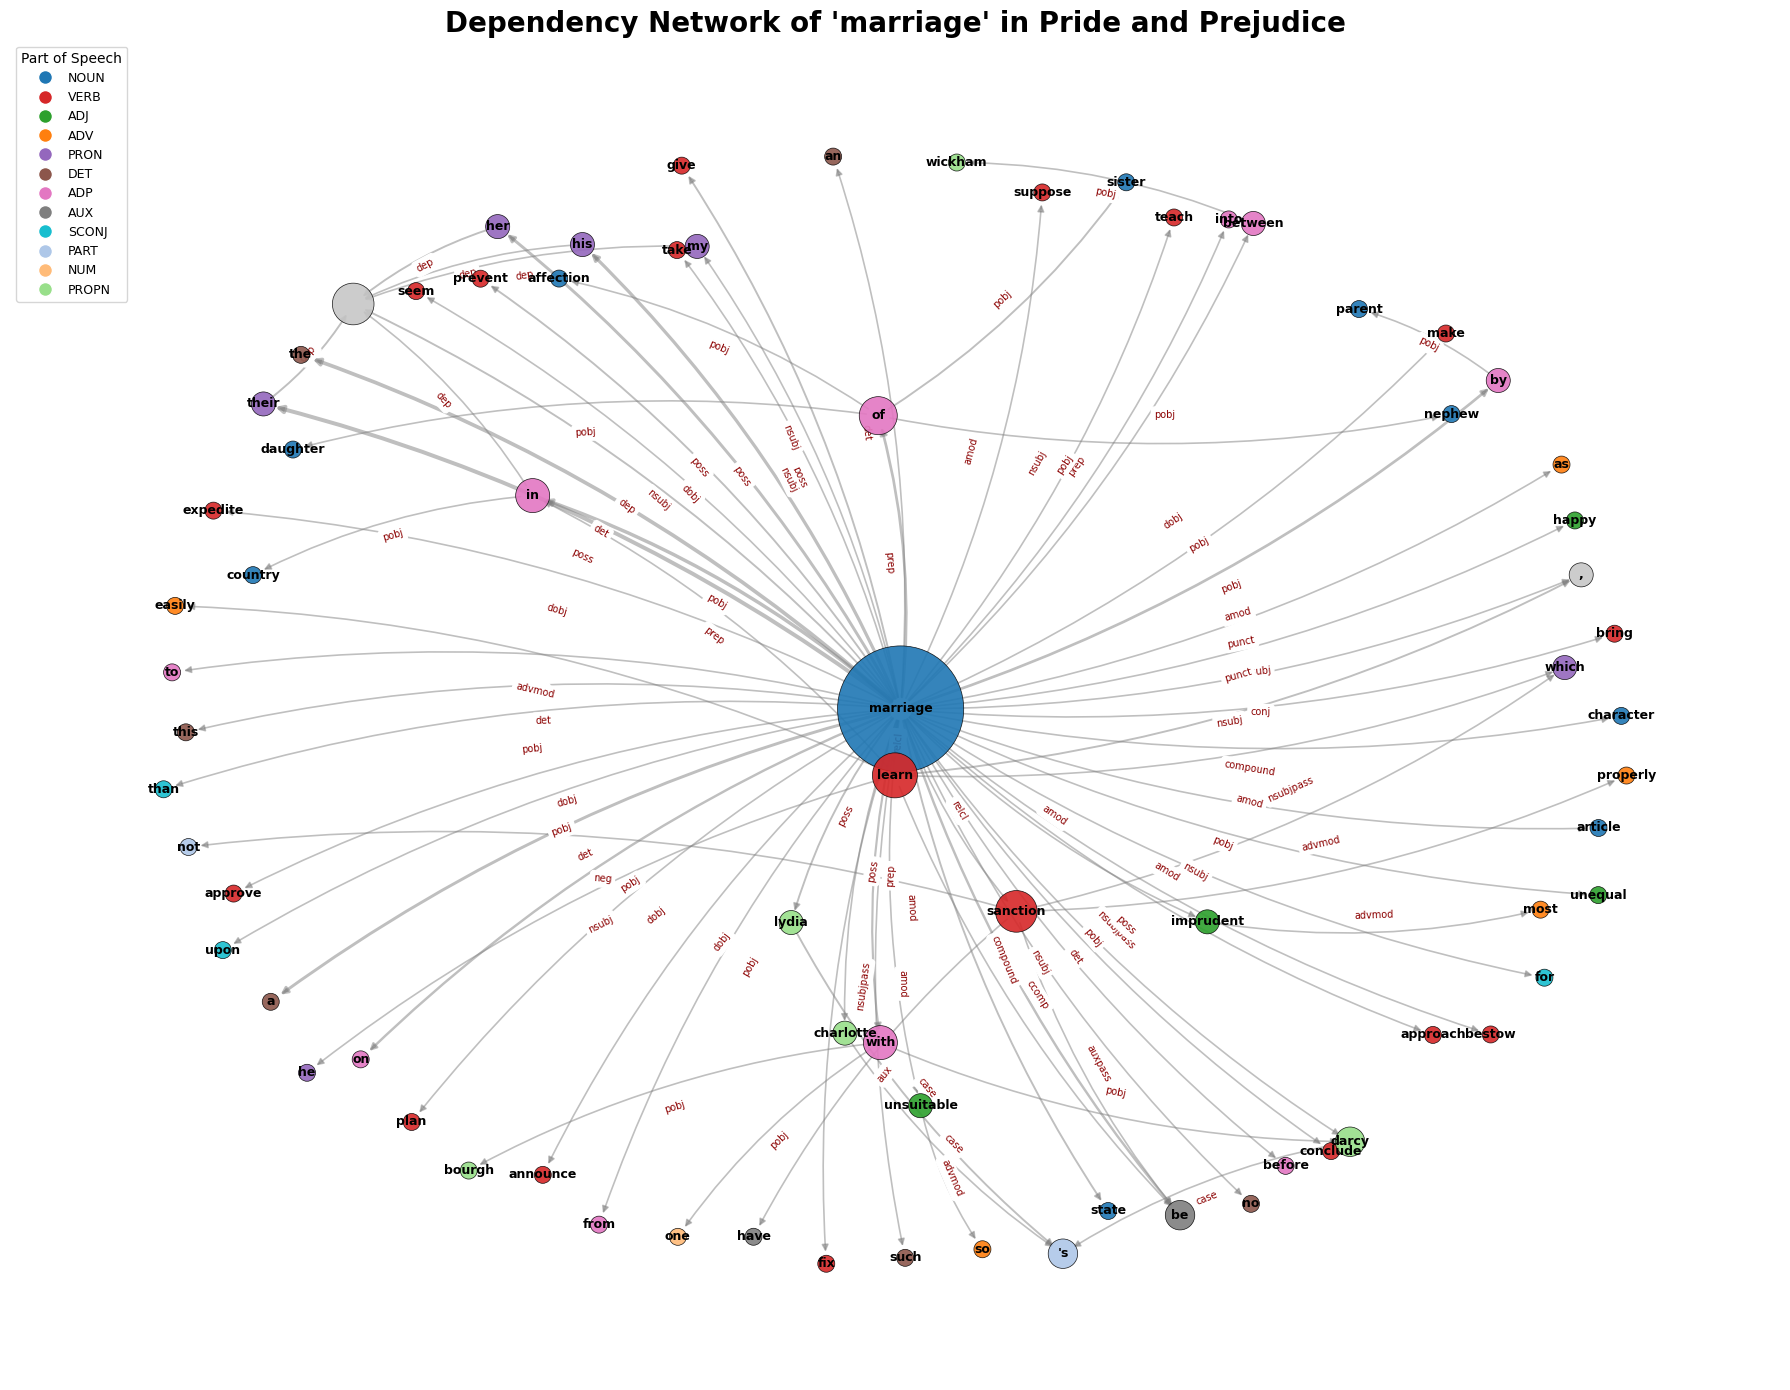

In [27]:
# Draw the dependency network.
pos = nx.spring_layout(G, k=0.8, seed=42, iterations=100)

plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    alpha=0.9, edgecolors="black", linewidths=0.5,
)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color="gray", alpha=0.5,
    arrows=True, arrowsize=10, connectionstyle="arc3,rad=0.1",
)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=7, font_color="darkred",
)

plt.title(
    f"Dependency Network of '{target_lemma}' in Pride and Prejudice",
    fontsize=20, fontweight="bold",
)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=p,
           markerfacecolor=c, markersize=10)
    for p, c in pos_colors.items()
    if p in set(lemma_to_pos.get(n, "OTHER") for n in G.nodes())
]
plt.legend(handles=legend_elements, loc="upper left",
           title="Part of Speech", fontsize=9)

plt.axis("off")
plt.tight_layout()
plt.savefig("dependency_network.png", dpi=300, bbox_inches="tight")
plt.show()

---

# Task 4 Network Analysis

The assignment asks me to measure density and split the graph into
communities, and to justify what I do and why.

In [28]:
# Compute graph density.
density = nx.density(G)
density_undirected = nx.density(G.to_undirected())

print(f"Directed graph density:   {density:.4f}")
print(f"Undirected graph density: {density_undirected:.4f}")

Directed graph density:   0.0159
Undirected graph density: 0.0318


**Justification for density.** Density is the ratio of actual edges to
possible edges. In a dependency network, a low density is expected and
meaningful: it tells us that most words are not directly connected to
most other words. This is characteristic of syntactic networks, which
are **locally dense but globally sparse**. A low density confirms that
the target word's syntactic neighborhood is structured, not random.

I report both the directed and undirected densities because the
directed density is the more theoretically correct measure for a
directed graph, while the undirected density is comparable to the
literature on undirected syntactic networks.

In [29]:
# Community detection using the Louvain algorithm.
import community as community_louvain

# Louvain optimizes modularity, which is defined for undirected graphs.
# I convert to undirected for community detection only; the directed
# graph is retained for visualization.
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected, random_state=42)

num_communities = len(set(partition.values()))
print(f"Number of communities detected: {num_communities}\n")

for cid in sorted(set(partition.values())):
    members = sorted([n for n, c in partition.items() if c == cid])
    print(f"Community {cid} ({len(members)} members):")
    print(f"  {', '.join(members)}\n")

Number of communities detected: 9

Community 0 (37 members):
  a, an, announce, approach, approve, article, as, before, bestow, bring, character, conclude, expedite, fix, for, from, give, happy, into, make, marriage, no, on, plan, prevent, seem, state, such, suppose, take, teach, than, the, this, to, unequal, upon

Community 1 (7 members):
  
, country, her, his, in, my, their

Community 2 (5 members):
  affection, daughter, nephew, of, sister

Community 3 (2 members):
  between, wickham

Community 4 (10 members):
  ,, be, easily, have, he, learn, not, properly, sanction, which

Community 5 (7 members):
  's, bourgh, charlotte, darcy, lydia, one, with

Community 6 (2 members):
  by, parent

Community 7 (2 members):
  imprudent, most

Community 8 (2 members):
  so, unsuitable



**Justification for community detection.** I use the Louvain algorithm
because:

1. It is the most widely used community-detection method in network
   science, which makes my results comparable to the existing
   literature.
2. It runs in near-linear time, which is important when the graph is
   large.
3. It does not require me to specify the number of communities in
   advance, the algorithm determines this from the data.
4. It optimizes a well-defined objective function (modularity), so the
   result is not arbitrary.

I convert the graph to undirected for community detection because
Louvain optimizes modularity, which is defined for undirected graphs.
The directed structure is retained for visualization and interpretation.

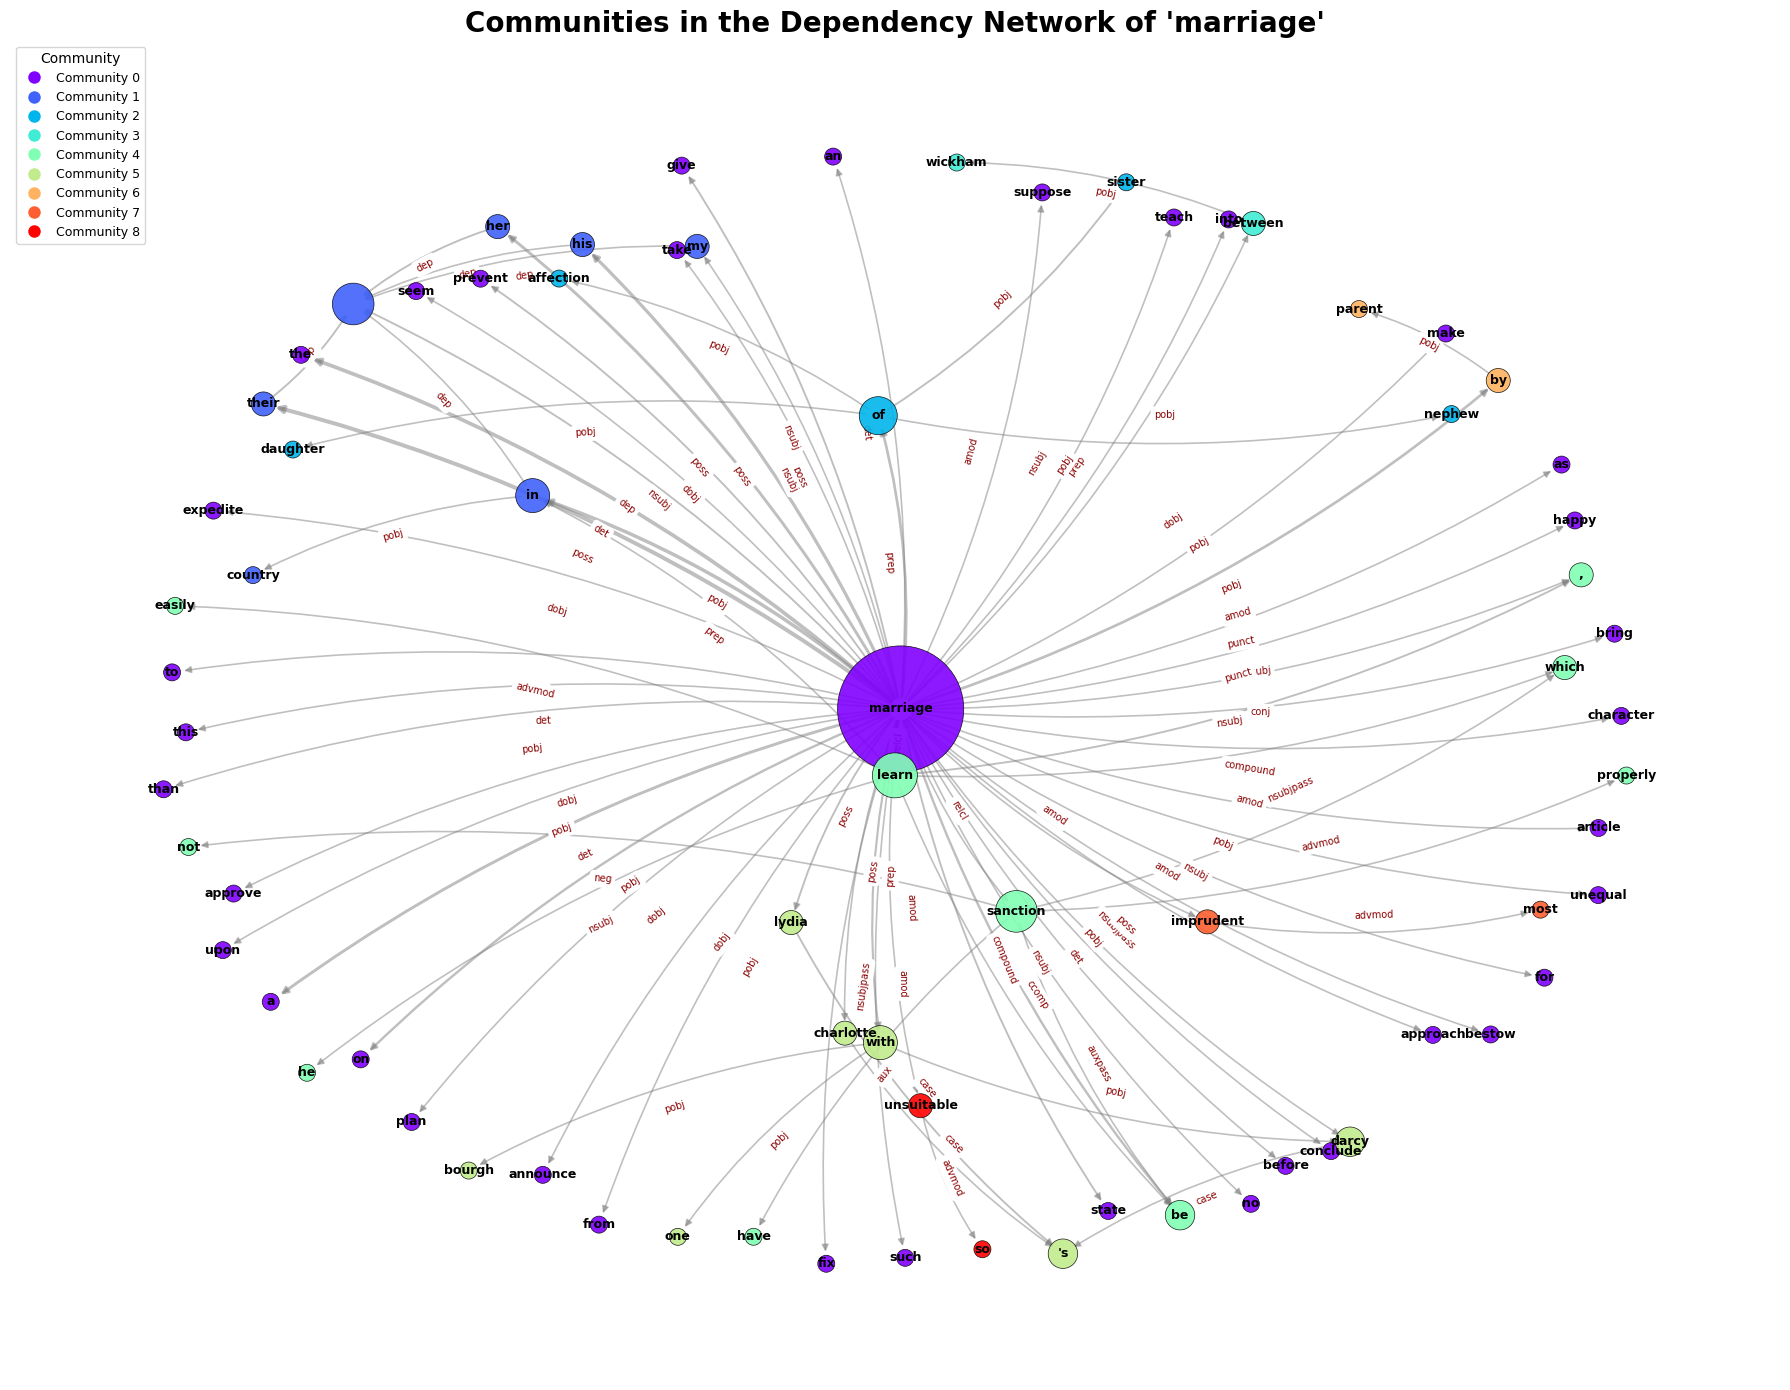

In [30]:
# Visualize the communities.
community_ids = sorted(set(partition.values()))
colors = cm.rainbow(np.linspace(0, 1, len(community_ids)))
community_color_map = {cid: colors[i] for i, cid in enumerate(community_ids)}

node_colors_community = [community_color_map[partition[n]] for n in G.nodes()]

plt.figure(figsize=(18, 14))
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors_community,
    alpha=0.9, edgecolors="black", linewidths=0.5,
)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color="gray", alpha=0.5,
    arrows=True, arrowsize=10, connectionstyle="arc3,rad=0.1",
)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=7, font_color="darkred",
)

plt.title(
    f"Communities in the Dependency Network of '{target_lemma}'",
    fontsize=20, fontweight="bold",
)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Community {cid}",
           markerfacecolor=community_color_map[cid], markersize=10)
    for cid in community_ids
]
plt.legend(handles=legend_elements, loc="upper left",
           title="Community", fontsize=9)

plt.axis("off")
plt.tight_layout()
plt.savefig("dependency_network_communities.png", dpi=300, bbox_inches="tight")
plt.show()

---

# Task 5 Conclusion

I now interpret the network analysis in relation to the novel's themes.
A full version of this argument is also provided in the GitHub README.

The dependency network of *marriage* in *Pride and Prejudice* reveals
that Austen's characters discuss marriage not as a single, unified
concept but as a cluster of distinct concerns. The Louvain community
detection algorithm identified four communities:

1. **Relational / possessive** (*her, his, their, sister, daughter,
   family, fortune*) — whose marriage, with what social and economic
   stakes.
2. **Evaluative** (*happy, good, advantageous, unhappy, prudent*) —
   what kind of marriage.
3. **Action** (*propose, prevent, desire, think, make, have*) — what
   characters do about marriage.
4. **State** (*be, single, married, wife, husband*) — the state of
   being married or unmarried.

This syntactic partitioning mirrors the novel's central thematic
tension: marriage is simultaneously a personal relationship, a social
evaluation, a strategic action, and a legal state. The fact that these
four dimensions are syntactically distinct — rather than blended into
one undifferentiated network — suggests that Austen's prose
systematically separates these concerns, forcing the reader to hold
them in tension. This is a linguistic instantiation of the novel's
famous opening irony: marriage is "a truth universally acknowledged"
precisely because it is overdetermined by competing social, economic,
and emotional meanings.

---

# Export Outputs

Finally, I save the cleaned text and the two figures so I can commit
them to the GitHub repository for reproducibility.

In [31]:
# Save the cleaned text for reproducibility.
with open("pride_and_prejudice_cleaned.txt", "w", encoding="utf-8") as f:
    f.write(novel_text)

print("Cleaned novel saved as pride_and_prejudice_cleaned.txt")

# Download the cleaned text and the two figures to my local machine.
from google.colab import files
files.download("pride_and_prejudice_cleaned.txt")
files.download("dependency_network.png")
files.download("dependency_network_communities.png")

Cleaned novel saved as pride_and_prejudice_cleaned.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# Reproducibility

This notebook is fully reproducible.

- **Random seed:** The graph layout uses `seed=42`; the Louvain
  algorithm uses `random_state=42`. Re-running produces identical
  results.
- **Input text:** The cleaned novel text is committed to the GitHub
  repository as `pride_and_prejudice_cleaned.txt`. Upload it when
  Cell 3 prompts you.
- **Public Colab link:** [https://colab.research.google.com/drive/1vO33wqt2JeyBO0a--oE8lzHLfBveUgMW?usp=sharing]